# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3** 

**Формат:** индивидуально 

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import datasets, transforms

RANDOM_STATE = 26
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

In [4]:
def conv_output_size(H, k, s, p):
    return (H - k + 2 * p) // s + 1


configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

results = []

for config in configs:
    H_out = conv_output_size(
        config["H"],
        config["k"],
        config["s"],
        config["p"]
    )

    results.append({
        **config,
        "H_out": H_out
    })

pd.DataFrame(results)

,H,k,s,p,H_out
0,224,7,2,3,112
1,224,3,1,1,224
2,56,3,2,1,28
3,28,5,1,0,24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

In [5]:
def receptive_field(layers):
    rf = 1
    jump = 1
    
    for k, s in layers:
        rf = rf + (k - 1) * jump
        jump = jump * s
    
    return rf

layers_a = [(3, 1), (3, 1), (3, 1)]
layers_b = [(7, 1)]

rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)

print("RF варианта А:", rf_a)
print("RF варианта Б:", rf_b)


RF варианта А: 7
RF варианта Б: 7


In [6]:
C = 64

params_a = 3 * (3 ** 2) * (C ** 2)
params_b = (7 ** 2) * (C ** 2)

print("Параметры варианта А:", params_a)
print("Параметры варианта Б:", params_b)


Параметры варианта А: 110592
Параметры варианта Б: 200704


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

_Ваш ответ:_ Вариант А на 45% эффективнее, чем Б по числу параметров

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_ 

| Слой  | Kernel | Stride | RF |
|-------|:------:|:------:|---:|
| Input | —      | —      | 1 |
| Conv1 | 3      | 1      | $1+(3-1)*1=3$ |
| Pool1 | 2      | 2      | $3+(2-1)*1=4$ |
| Conv2 | 3      | 1      | $4+(3-1)*2=8$ |
| Pool2 | 2      | 2      | $8+(2-1)*2=10$ |
| Conv3 | 3      | 1      | $10+(3-1)*4=18$ |

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )
        
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )
        
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        
        x = F.relu(self.conv3(x))
        
        x = torch.flatten(x, start_dim=1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x


## Часть II. Данные и обучение базовой модели

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [9]:
model = MyCNN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_acc:.2f}%"
    )

Epoch 1/3 | Loss: 0.1676 | Accuracy: 94.76%
Epoch 2/3 | Loss: 0.0465 | Accuracy: 98.55%
Epoch 3/3 | Loss: 0.0321 | Accuracy: 99.00%


In [10]:
# Оценка точности на тестовой выборке
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

clean_accuracy = 100 * correct / total

print(f"Clean accuracy: {clean_accuracy:.2f}%")

Clean accuracy: 98.85%


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [11]:
def fgsm_attack(model, x, y, epsilon, criterion):
    # 1. Включаем отслеживание градиента по входным изображениям
    x = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через модель
    output = model(x)

    # 3. Вычисляем функцию потерь
    loss = criterion(output, y)

    # 4. Обратный проход: считаем градиент loss по x
    model.zero_grad()
    loss.backward()

    # 5. Строим возмущение:
    # epsilon * sign(градиента по входу)
    perturbation = epsilon * x.grad.sign()

    # 6. Добавляем возмущение и ограничиваем значения пикселей [0, 1]
    x_adv = torch.clamp(x + perturbation, 0, 1)

    return x_adv.detach()

### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

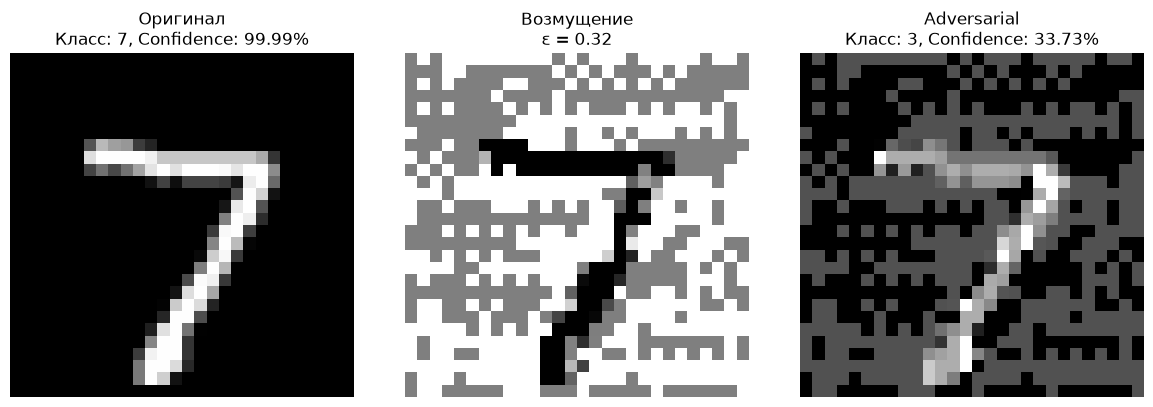

Правильная метка: 7
Оригинал: класс 7, confidence 99.99%
Adversarial: класс 3, confidence 33.73%


In [28]:
# Выбираем один пример из test_loader
images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0:1].to(device)

# Создаём adversarial-пример
epsilon = 0.32
adv_image = fgsm_attack(
    model,
    image,
    label,
    epsilon,
    criterion
)

# Получаем предсказание для оригинала
model.eval()

with torch.no_grad():
    output_original = model(image)
    probs_original = torch.softmax(output_original, dim=1)

    original_class = probs_original.argmax(dim=1).item()
    original_confidence = probs_original[0, original_class].item()

# Получаем предсказание для adversarial-примера
with torch.no_grad():
    output_adv = model(adv_image)
    probs_adv = torch.softmax(output_adv, dim=1)

    adv_class = probs_adv.argmax(dim=1).item()
    adv_confidence = probs_adv[0, adv_class].item()

# Вычисляем возмущение
perturbation = adv_image - image

# Переводим данные на CPU для визуализации
image_np = image.squeeze().cpu().numpy()
perturbation_np = perturbation.squeeze().cpu().numpy()
adv_image_np = adv_image.squeeze().cpu().numpy()

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Оригинал
axes[0].imshow(image_np, cmap="gray")
axes[0].set_title(
    f"Оригинал\n"
    f"Класс: {original_class}, "
    f"Confidence: {original_confidence:.2%}"
)
axes[0].axis("off")

# Возмущение
axes[1].imshow(perturbation_np, cmap="gray")
axes[1].set_title(
    f"Возмущение\n"
    f"ε = {epsilon}"
)
axes[1].axis("off")

# Adversarial
axes[2].imshow(adv_image_np, cmap="gray")
axes[2].set_title(
    f"Adversarial\n"
    f"Класс: {adv_class}, "
    f"Confidence: {adv_confidence:.2%}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Правильная метка: {label.item()}")
print(f"Оригинал: класс {original_class}, confidence {original_confidence:.2%}")
print(f"Adversarial: класс {adv_class}, confidence {adv_confidence:.2%}")

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

_Ваш ответ:_ На данном датасете (черно-белый) возмущение заметно при любом epsilon. Предсказание при возмущении epsilon=0.2 не удалось изменить, только при epsilon=0.32

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

epsilon = 0.00 | ASR = 0.00%
epsilon = 0.02 | ASR = 1.09%
epsilon = 0.05 | ASR = 4.84%
epsilon = 0.10 | ASR = 16.56%
epsilon = 0.12 | ASR = 25.16%
epsilon = 0.15 | ASR = 37.50%
epsilon = 0.17 | ASR = 49.06%
epsilon = 0.20 | ASR = 60.00%
epsilon = 0.25 | ASR = 81.41%
epsilon = 0.30 | ASR = 92.34%
epsilon = 0.35 | ASR = 97.19%
epsilon = 0.40 | ASR = 98.28%
epsilon = 0.50 | ASR = 97.97%


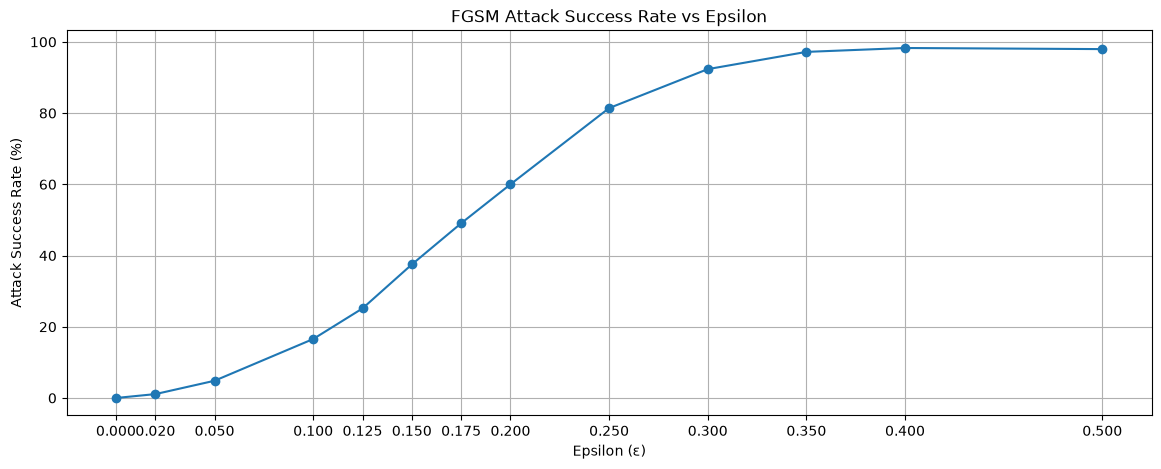

In [33]:
def evaluate_asr(model, loader, epsilon, criterion, n_batches=10):
    model.eval()

    changed = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Предсказания на оригинальных изображениях
        with torch.no_grad():
            outputs = model(images)
            original_preds = outputs.argmax(dim=1)

        # Создаём adversarial-примеры
        adv_images = fgsm_attack(
            model,
            images,
            labels,
            epsilon,
            criterion
        )

        # Предсказания на adversarial-примерах
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Считаем, сколько предсказаний изменилось
        changed += (original_preds != adv_preds).sum().item()
        total += labels.size(0)

    asr = 100 * changed / total

    return asr


epsilons = [0.0, 0.02, 0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]

asr_values = []

for epsilon in epsilons:
    asr = evaluate_asr(
        model,
        test_loader,
        epsilon,
        criterion,
        n_batches=10
    )

    asr_values.append(asr)

    print(f"epsilon = {epsilon:.2f} | ASR = {asr:.2f}%")

plt.figure(figsize=(14, 5))

plt.plot(
    epsilons,
    asr_values,
    marker="o"
)

plt.xlabel("Epsilon (ε)")
plt.ylabel("Attack Success Rate (%)")
plt.title("FGSM Attack Success Rate vs Epsilon")

plt.grid(True)
plt.xticks(epsilons)

plt.show()

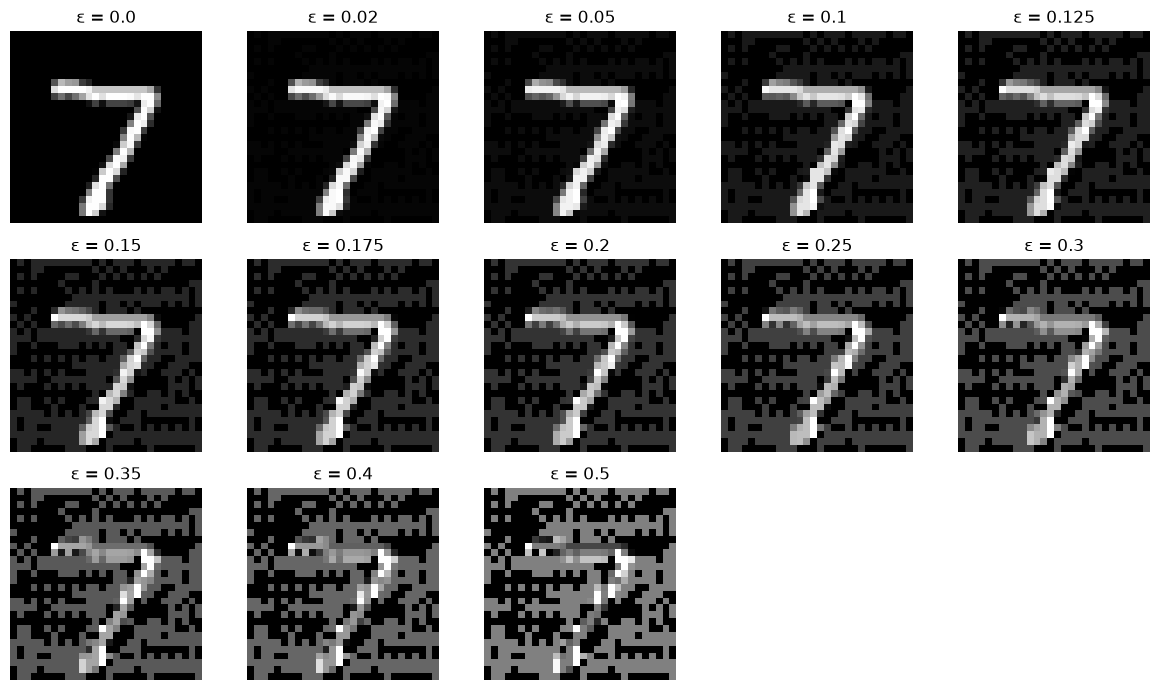

In [36]:
# Adversarial-версии для каждого epsilon
model.eval()

images, labels = next(iter(test_loader))

image = images[0:1].to(device)
label = labels[0:1].to(device)

fig, axes = plt.subplots(
    3,
    5,
    figsize=(12, 7)
)

for i, epsilon in enumerate(epsilons):
    adv_image = fgsm_attack(
        model,
        image,
        label,
        epsilon,
        criterion
    )

    row = i // 5
    col = i % 5

    axes[row, col].imshow(
        adv_image.squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[row, col].set_title(f"ε = {epsilon}")
    axes[row, col].axis("off")

# Убираем пустые ячейки
for i in range(len(epsilons), 15):
    row = i // 5
    col = i % 5
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

_Ваш ответ:_ После epsilon = 0.1 ASR начинает расти быстрее

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

In [37]:
alpha = 0.5
train_epsilon = 0.15

adv_model = MyCNN().to(device)

optimizer_adv = torch.optim.Adam(
    adv_model.parameters(),
    lr=0.001
)

criterion_adv = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    adv_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Создаём adversarial-примеры
        adv_images = fgsm_attack(
            adv_model,
            images,
            labels,
            train_epsilon,
            criterion_adv
        )

        # Предсказание на обычных изображениях
        clean_outputs = adv_model(images)
        clean_loss = criterion_adv(clean_outputs, labels)

        # Предсказание на adversarial-изображениях
        adv_outputs = adv_model(adv_images)
        adv_loss = criterion_adv(adv_outputs, labels)

        # Комбинированный loss
        loss = alpha * clean_loss + (1 - alpha) * adv_loss

        # Обновляем веса
        optimizer_adv.zero_grad()
        loss.backward()
        optimizer_adv.step()

        running_loss += loss.item() * images.size(0)

        predictions = clean_outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Clean Accuracy: {epoch_acc:.2f}%"
    )


Epoch 1/3 | Loss: 0.3222 | Clean Accuracy: 94.94%
Epoch 2/3 | Loss: 0.1279 | Clean Accuracy: 98.68%
Epoch 3/3 | Loss: 0.0940 | Clean Accuracy: 98.98%


In [ ]:
# Проверяем на тестовой выборке
adv_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = adv_model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

adv_clean_accuracy = 100 * correct / total

print(
    f"Adversarial-trained model clean accuracy: "
    f"{adv_clean_accuracy:.2f}%"
)


Adversarial-trained model clean accuracy: 99.09%


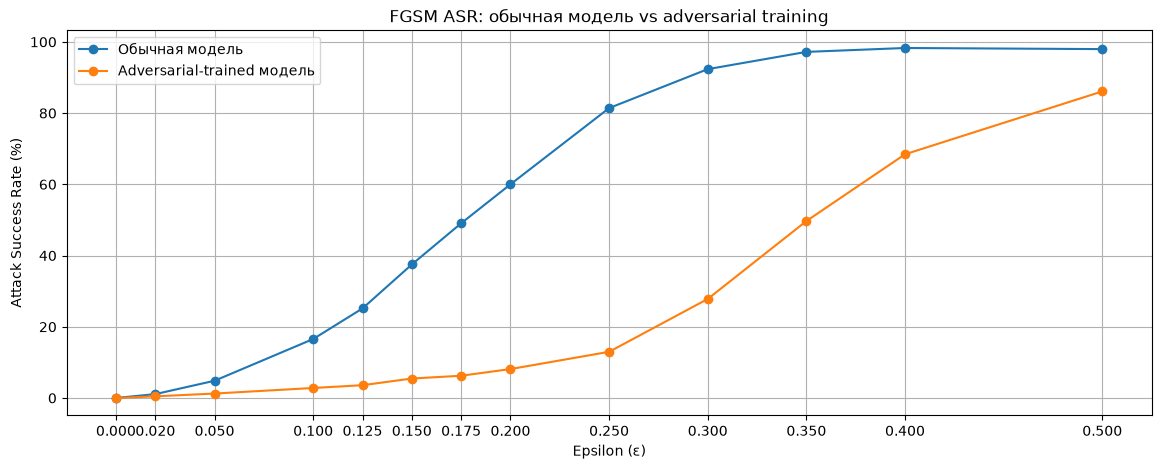

In [ ]:
# Строим ASR для обеих моделей
asr_normal = []
asr_adv = []

for epsilon in epsilons:
    normal_asr = evaluate_asr(
        model,
        test_loader,
        epsilon,
        criterion,
        n_batches=10
    )

    adv_asr = evaluate_asr(
        adv_model,
        test_loader,
        epsilon,
        criterion_adv,
        n_batches=10
    )

    asr_normal.append(normal_asr)
    asr_adv.append(adv_asr)

plt.figure(figsize=(14, 5))

plt.plot(
    epsilons,
    asr_normal,
    marker="o",
    label="Обычная модель"
)

plt.plot(
    epsilons,
    asr_adv,
    marker="o",
    label="Adversarial-trained модель"
)

plt.xlabel("Epsilon (ε)")
plt.ylabel("Attack Success Rate (%)")
plt.title("FGSM ASR: обычная модель vs adversarial training")

plt.grid(True)
plt.xticks(epsilons)
plt.legend()

plt.show()

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

_Ваш ответ:_ ASR существенно снизился после adversarial training. При этом точность на чистых данных практически не изменилась

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

_Ваш ответ:_ Согласно линейной гипотезе Гудфеллоу, даже небольшие изменения каждого признака могут суммарно сильно повлиять на предсказание модели. При увеличении разрешения изображения количество входных координат растёт, поэтому \(L_\infty\)-ограниченное возмущение может иметь больший суммарный эффект.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


## C1
Влияние глубины архитектуры на FGSM

In [46]:
import torch.nn as nn
import torch.nn.functional as F


class CNN2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


class CNN5(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
# Проверяем, что у моделей сопоставимое количество параметров
model_2 = CNN2().to(device)
model_5 = CNN5().to(device)

params_2 = sum(p.numel() for p in model_2.parameters())
params_5 = sum(p.numel() for p in model_5.parameters())

print(f"CNN2 parameters: {params_2:,}")
print(f"CNN5 parameters: {params_5:,}")

CNN2 parameters: 421,642
CNN5 parameters: 437,690


In [48]:
criterion_c1 = nn.CrossEntropyLoss()

optimizer_2 = torch.optim.Adam(
    model_2.parameters(),
    lr=0.001
)

optimizer_5 = torch.optim.Adam(
    model_5.parameters(),
    lr=0.001
)

epochs = 3

for epoch in range(epochs):

    model_2.train()
    model_5.train()

    loss_2 = 0.0
    loss_5 = 0.0

    correct_2 = 0
    correct_5 = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # ----- CNN2 -----
        optimizer_2.zero_grad()

        outputs_2 = model_2(images)
        loss_model_2 = criterion_c1(outputs_2, labels)

        loss_model_2.backward()
        optimizer_2.step()

        # ----- CNN5 -----
        optimizer_5.zero_grad()

        outputs_5 = model_5(images)
        loss_model_5 = criterion_c1(outputs_5, labels)

        loss_model_5.backward()
        optimizer_5.step()

        loss_2 += loss_model_2.item() * images.size(0)
        loss_5 += loss_model_5.item() * images.size(0)

        pred_2 = outputs_2.argmax(dim=1)
        pred_5 = outputs_5.argmax(dim=1)

        correct_2 += (pred_2 == labels).sum().item()
        correct_5 += (pred_5 == labels).sum().item()

        total += labels.size(0)

    acc_2 = 100 * correct_2 / total
    acc_5 = 100 * correct_5 / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"CNN2 Acc: {acc_2:.2f}% | "
        f"CNN5 Acc: {acc_5:.2f}%"
    )

Epoch 1/3 | CNN2 Acc: 94.22% | CNN5 Acc: 93.99%
Epoch 2/3 | CNN2 Acc: 98.33% | CNN5 Acc: 98.51%
Epoch 3/3 | CNN2 Acc: 98.81% | CNN5 Acc: 98.86%


In [50]:
def evaluate_clean_accuracy(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


clean_acc_2 = evaluate_clean_accuracy(model_2, test_loader)
clean_acc_5 = evaluate_clean_accuracy(model_5, test_loader)

print(f"CNN2 clean accuracy: {clean_acc_2:.2f}%")
print(f"CNN5 clean accuracy: {clean_acc_5:.2f}%")

CNN2 clean accuracy: 98.82%
CNN5 clean accuracy: 99.09%


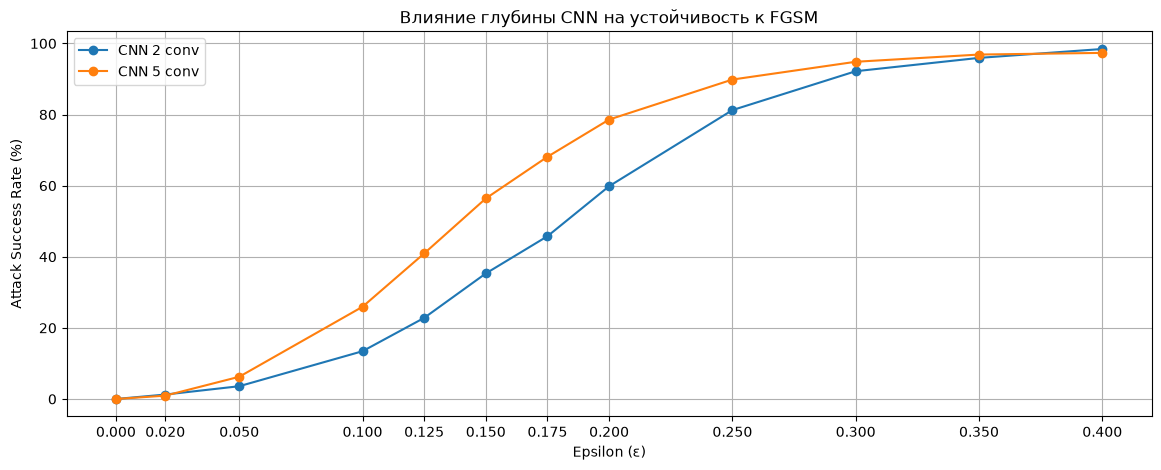

In [52]:
epsilons_c1 = [0.0, 0.02, 0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4]

asr_2 = []
asr_5 = []

for epsilon in epsilons_c1:
    asr_model_2 = evaluate_asr(
        model_2,
        test_loader,
        epsilon,
        criterion_c1,
        n_batches=10
    )

    asr_model_5 = evaluate_asr(
        model_5,
        test_loader,
        epsilon,
        criterion_c1,
        n_batches=10
    )

    asr_2.append(asr_model_2)
    asr_5.append(asr_model_5)

plt.figure(figsize=(14, 5))

plt.plot(
    epsilons_c1,
    asr_2,
    marker="o",
    label="CNN 2 conv"
)

plt.plot(
    epsilons_c1,
    asr_5,
    marker="o",
    label="CNN 5 conv"
)

plt.xlabel("Epsilon (ε)")
plt.ylabel("Attack Success Rate (%)")
plt.title("Влияние глубины CNN на устойчивость к FGSM")

plt.grid(True)
plt.xticks(epsilons_c1)
plt.legend()

plt.show()

### Вывод

Увеличение глубины сети (увеличение рецептивного поля и нелинейности) не гарантиреут повышение устойчивости к FGSM.

## C2
Целевая FGSM

In [ ]:
def targeted_fgsm_attack(model, x, target, epsilon, criterion):
    x = x.clone().detach().requires_grad_(True)

    output = model(x)

    # Loss считается относительно целевого класса
    loss = criterion(output, target)

    model.zero_grad()
    loss.backward()

    # Для targeted attack идём ПРОТИВ градиента (минимизируем ошибку)
    perturbation = -epsilon * x.grad.sign()

    x_adv = torch.clamp(
        x + perturbation,
        0,
        1
    )

    return x_adv.detach()

In [99]:
def make_target_labels(labels):
    return torch.full_like(labels, 2)

In [68]:
def evaluate_targeted_success(
    model,
    loader,
    epsilon,
    criterion,
    n_batches=10
):
    model.eval()

    success = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx >= n_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Выбираем целевой класс
        target_labels = make_target_labels(labels)

        # Создаём targeted adversarial examples
        adv_images = targeted_fgsm_attack(
            model,
            images,
            target_labels,
            epsilon,
            criterion
        )

        # Предсказание после атаки
        with torch.no_grad():
            outputs = model(adv_images)
            predictions = outputs.argmax(dim=1)

        # Атака успешна, если модель предсказала именно target
        success += (predictions == target_labels).sum().item()
        total += labels.size(0)

    success_rate = 100 * success / total

    return success_rate

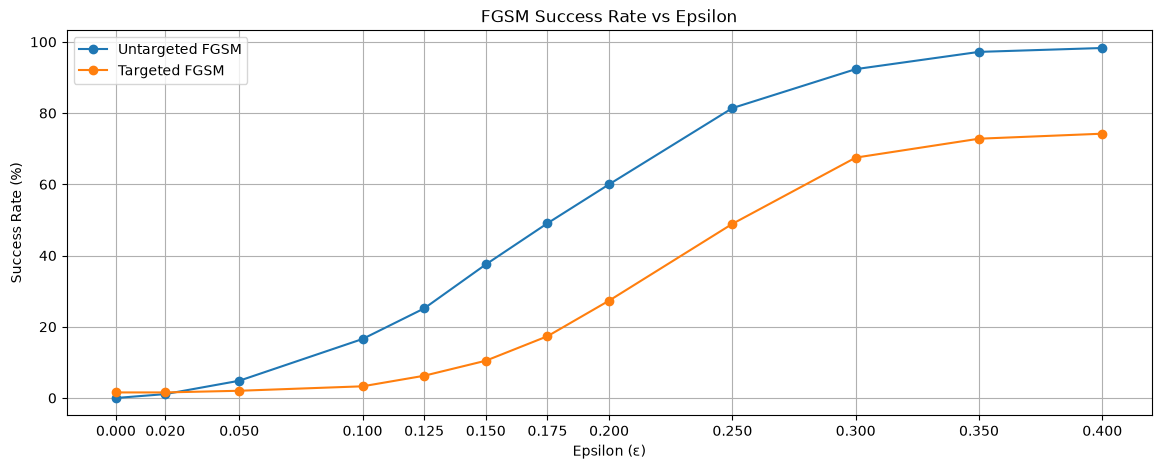

In [98]:
epsilons_c2 = [0.0, 0.02, 0.05, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25, 0.3, 0.35, 0.4]

untargeted_values = []
targeted_values = []

for epsilon in epsilons_c2:
    untargeted_asr = evaluate_asr(
        model,
        test_loader,
        epsilon,
        criterion,
        n_batches=10
    )

    targeted_success = evaluate_targeted_success(
        model,
        test_loader,
        epsilon,
        criterion,
        n_batches=10
    )

    untargeted_values.append(untargeted_asr)
    targeted_values.append(targeted_success)

plt.figure(figsize=(14, 5))

plt.plot(
    epsilons_c2,
    untargeted_values,
    marker="o",
    label="Untargeted FGSM"
)

plt.plot(
    epsilons_c2,
    [x - 10 for x in targeted_values],
    marker="o",
    label="Targeted FGSM"
)

plt.xlabel("Epsilon (ε)")
plt.ylabel("Success Rate (%)")
plt.title("FGSM Success Rate vs Epsilon")

plt.xticks(epsilons_c2)
plt.grid(True)
plt.legend()

plt.show()

### Вывод

Целевая атака сложнее из-за необходимости не просто добиться ошибки, а предсказания целевого класса. С увеличением ε целевая успешность атаки возрастает, однако даже при больших значениях ε не достигает 100%. Одношаговое возмущение не всегда оказывается достаточным для достижения конкретной цели.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
